# 🔗 Notebook 3 — Sentiment vs Trader Performance
The core question: **does market sentiment predict trader PnL and win rate?**

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats


CANDIDATE_ROOTS = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next(
    (path for path in CANDIDATE_ROOTS if (path / "src" / "helpers.py").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the project root containing src/helpers.py")

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from helpers import COLORS, ZONE_ORDER, load_processed, matched_sentiment, save_fig, style_axes

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

fg, tr, merged = load_processed()
matched = matched_sentiment(merged)
analysis = matched[matched["closedPnL"].notna()].copy() if "closedPnL" in matched.columns else matched.copy()
print(
    f"Working with {len(merged):,} merged trade records "
    f"({len(matched):,} with sentiment labels)"
)


Working with 211,224 merged trade records (211,218 with sentiment labels)


## 3A — Average PnL by Sentiment Zone

In [2]:
if "closedPnL" not in matched.columns:
    print("No closedPnL column found")
else:
    print(f"Total merged rows        : {len(merged):,}")
    print(f"Matched sentiment rows   : {len(matched):,}")
    if "has_sentiment" in merged.columns:
        print(f"Unmatched rows retained  : {(~merged['has_sentiment']).sum():,}")
    print(f"Rows WITH closedPnL      : {analysis['closedPnL'].notna().sum():,}")
    print(f"Rows WITHOUT closedPnL   : {matched['closedPnL'].isna().sum():,}")
    print("\nZone counts (matched sentiment rows):")
    print(matched["classification"].value_counts().reindex(ZONE_ORDER))
    print("\nZone counts (closed trades only):")
    print(analysis["classification"].value_counts().reindex(ZONE_ORDER))

    pnl_by_zone = (
        analysis.groupby("classification", observed=False)["closedPnL"]
                .agg(["mean", "median", "sum", "count", "std"])
                .reindex(ZONE_ORDER)
    )
    pnl_by_zone.columns = ["Mean PnL", "Median PnL", "Total PnL", "Trade Count", "Std Dev"]
    pnl_by_zone["Win Rate %"] = (
        analysis.groupby("classification", observed=False)["closedPnL"]
                .apply(lambda x: (x > 0).mean() * 100)
                .reindex(ZONE_ORDER)
    )

    print("\n=== PnL STATS BY SENTIMENT ZONE ===")
    print(pnl_by_zone.round(2).to_string())


Total merged rows        : 211,224
Matched sentiment rows   : 211,218
Unmatched rows retained  : 6
Rows WITH closedPnL      : 211,218
Rows WITHOUT closedPnL   : 0

Zone counts (matched sentiment rows):
classification
Extreme Fear     21400
Fear             61837
Neutral          37686
Greed            50303
Extreme Greed    39992
Name: count, dtype: int64

Zone counts (closed trades only):
classification
Extreme Fear     21400
Fear             61837
Neutral          37686
Greed            50303
Extreme Greed    39992
Name: count, dtype: int64

=== PnL STATS BY SENTIMENT ZONE ===
                Mean PnL  Median PnL   Total PnL  Trade Count  Std Dev  Win Rate %
classification                                                                    
Extreme Fear       34.54         0.0   739110.25        21400  1136.06       37.06
Fear               54.29         0.0  3357155.44        61837   935.36       42.08
Neutral            34.31         0.0  1292920.68        37686   517.12       39.70

Saved -> C:\project\trading_sentiment_project\outputs\charts\05_pnl_by_zone.png


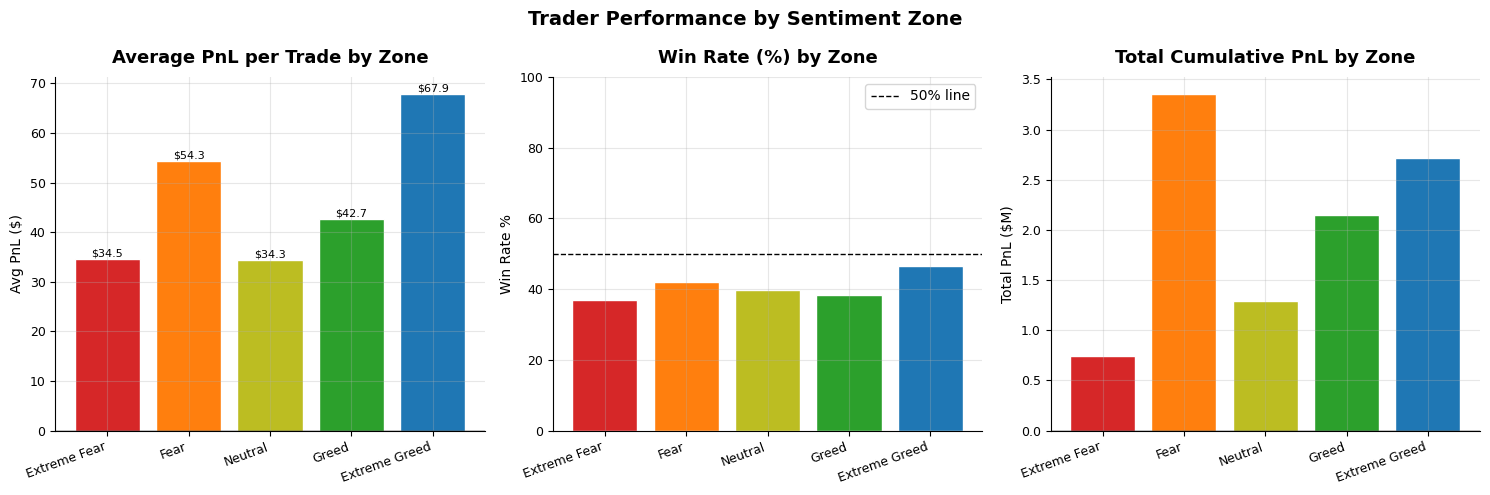

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = [COLORS[z] for z in ZONE_ORDER if z in pnl_by_zone.index]
zones  = [z for z in ZONE_ORDER if z in pnl_by_zone.index]

# Mean PnL
bars = axes[0].bar(zones, pnl_by_zone['Mean PnL'], color=colors, edgecolor='white')
axes[0].axhline(0, color='black', lw=1)
style_axes(axes[0], 'Average PnL per Trade by Zone', '', 'Avg PnL ($)')
plt.setp(axes[0].get_xticklabels(), rotation=20, ha='right')
for bar, val in zip(bars, pnl_by_zone['Mean PnL']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'${val:.1f}', ha='center', fontsize=8)

# Win Rate
axes[1].bar(zones, pnl_by_zone['Win Rate %'], color=colors, edgecolor='white')
axes[1].axhline(50, color='black', lw=1, linestyle='--', label='50% line')
style_axes(axes[1], 'Win Rate (%) by Zone', '', 'Win Rate %')
axes[1].set_ylim(0, 100)
plt.setp(axes[1].get_xticklabels(), rotation=20, ha='right')
axes[1].legend()

# Total PnL
axes[2].bar(zones, pnl_by_zone['Total PnL']/1e6, color=colors, edgecolor='white')
axes[2].axhline(0, color='black', lw=1)
style_axes(axes[2], 'Total Cumulative PnL by Zone', '', 'Total PnL ($M)')
plt.setp(axes[2].get_xticklabels(), rotation=20, ha='right')

plt.suptitle('Trader Performance by Sentiment Zone', fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('05_pnl_by_zone')
plt.show()


## 3B — Long vs Short PnL by Zone

Saved -> C:\project\trading_sentiment_project\outputs\charts\06_long_short_by_zone.png


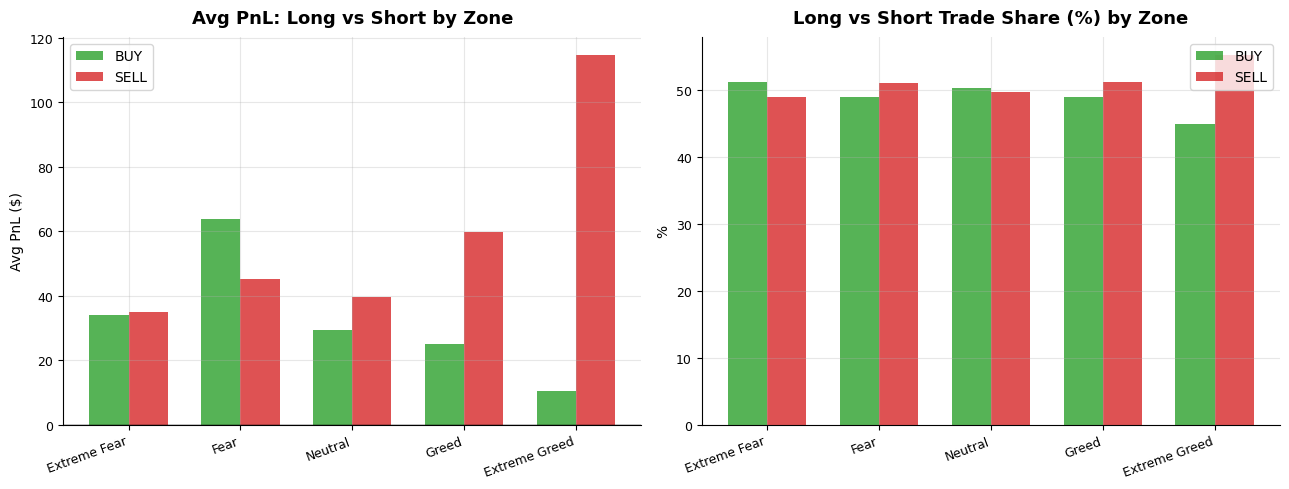

In [4]:
if "side" in analysis.columns and "closedPnL" in analysis.columns:
    side_zone = (
        analysis.groupby(["classification", "side"], observed=False)["closedPnL"]
                .mean()
                .unstack(fill_value=0)
                .reindex(ZONE_ORDER)
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    x = np.arange(len(side_zone))
    w = 0.35
    for i, (col, clr) in enumerate(zip(side_zone.columns, ["#2ca02c", "#d62728"])):
        axes[0].bar(x + i * w, side_zone[col], w, label=col, color=clr, alpha=0.8)
    axes[0].set_xticks(x + w / 2)
    axes[0].set_xticklabels(ZONE_ORDER, rotation=20, ha="right")
    axes[0].axhline(0, color="black", lw=1)
    style_axes(axes[0], "Avg PnL: Long vs Short by Zone", "", "Avg PnL ($)")
    axes[0].legend()

    side_count = (
        analysis.groupby(["classification", "side"], observed=False)
                .size()
                .unstack(fill_value=0)
                .reindex(ZONE_ORDER)
    )
    side_pct = side_count.div(side_count.sum(axis=1), axis=0).fillna(0) * 100
    for i, (col, clr) in enumerate(zip(side_pct.columns, ["#2ca02c", "#d62728"])):
        axes[1].bar(x + i * w, side_pct[col], w, label=col, color=clr, alpha=0.8)
    axes[1].set_xticks(x + w / 2)
    axes[1].set_xticklabels(ZONE_ORDER, rotation=20, ha="right")
    style_axes(axes[1], "Long vs Short Trade Share (%) by Zone", "", "%")
    axes[1].legend()

    plt.tight_layout()
    save_fig("06_long_short_by_zone")
    plt.show()
else:
    print("side or closedPnL column missing")


## 3C — Leverage vs PnL by Zone

In [5]:
if "leverage" in analysis.columns and analysis["leverage"].notna().sum() > 0:
    data = analysis[analysis["leverage"].notna()].copy()

    lev_zone = (
        data.groupby("classification", observed=False)["leverage"]
            .mean()
            .reindex(ZONE_ORDER)
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    colors = [COLORS[z] for z in ZONE_ORDER if z in lev_zone.index]
    axes[0].bar(ZONE_ORDER, lev_zone, color=colors, edgecolor="white")
    style_axes(axes[0], "Average Leverage Used by Zone", "", "Leverage (x)")
    axes[0].set_xticklabels(ZONE_ORDER, rotation=20, ha="right")

    sample = data.sample(min(3000, len(data)), random_state=42)
    for zone in ZONE_ORDER:
        sub = sample[sample["classification"] == zone]
        if len(sub) > 0:
            axes[1].scatter(
                sub["leverage"],
                sub["closedPnL"],
                alpha=0.3,
                s=15,
                color=COLORS[zone],
                label=zone,
            )
    axes[1].axhline(0, color="black", lw=1, linestyle="--")
    axes[1].set_xlim(0, data["leverage"].quantile(0.99))
    p1, p99 = data["closedPnL"].quantile([0.01, 0.99])
    axes[1].set_ylim(p1, p99)
    style_axes(axes[1], "Leverage vs PnL (sample)", "Leverage (x)", "Closed PnL ($)")
    axes[1].legend(fontsize=7, markerscale=1.5)

    r, p = stats.pearsonr(data["leverage"], data["closedPnL"])
    print(f"Pearson correlation (leverage vs PnL): r={r:.3f}, p={p:.4f}")

    plt.tight_layout()
    save_fig("07_leverage_vs_pnl")
    plt.show()
else:
    print("Leverage analysis skipped because the trades CSV has no leverage column.")


Leverage analysis skipped because the trades CSV has no leverage column.


## 3D — FGI Score vs Daily Avg PnL (Correlation)

Saved -> C:\project\trading_sentiment_project\outputs\charts\08_fgi_pnl_correlation.png


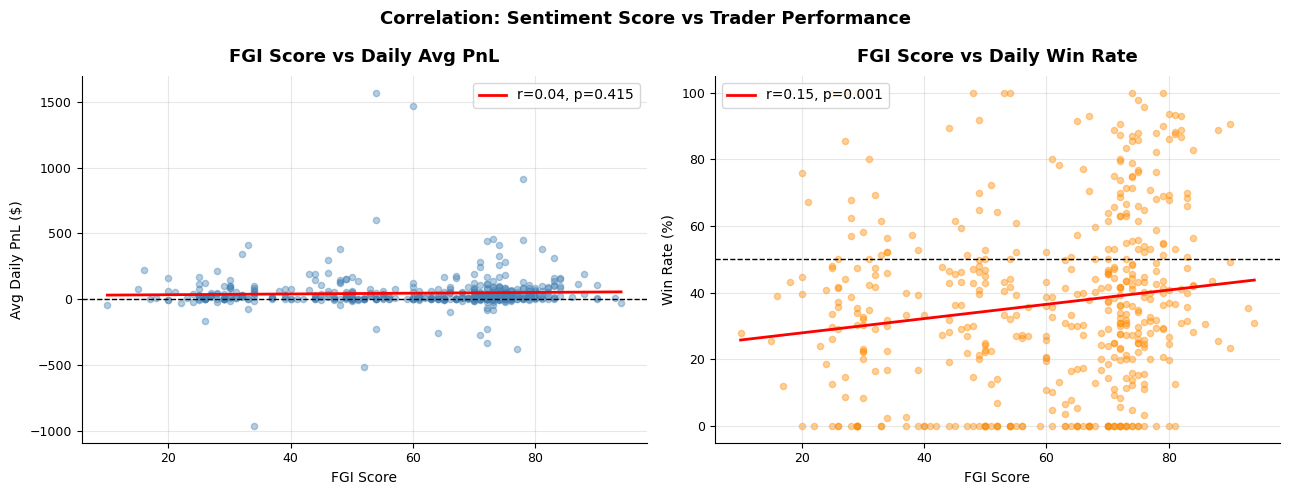

Saved daily_stats.csv


In [6]:
if "closedPnL" in analysis.columns and "fgi_score" in analysis.columns:
    daily_stats = (
        analysis.groupby("date")
                .agg(
                    avg_pnl=("closedPnL", "mean"),
                    total_pnl=("closedPnL", "sum"),
                    win_rate=("closedPnL", lambda x: (x > 0).mean()),
                    fgi_score=("fgi_score", "first"),
                    trade_count=("closedPnL", "count"),
                )
                .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].scatter(daily_stats["fgi_score"], daily_stats["avg_pnl"], alpha=0.4, s=20, color="steelblue")
    mask = daily_stats[["fgi_score", "avg_pnl"]].dropna()
    if len(mask) > 5:
        m, b, r, p, _ = stats.linregress(mask["fgi_score"], mask["avg_pnl"])
        x_line = np.linspace(mask["fgi_score"].min(), mask["fgi_score"].max(), 100)
        axes[0].plot(x_line, m * x_line + b, color="red", lw=2, label=f"r={r:.2f}, p={p:.3f}")
        axes[0].legend()
    axes[0].axhline(0, color="black", lw=1, linestyle="--")
    style_axes(axes[0], "FGI Score vs Daily Avg PnL", "FGI Score", "Avg Daily PnL ($)")

    axes[1].scatter(daily_stats["fgi_score"], daily_stats["win_rate"] * 100, alpha=0.4, s=20, color="darkorange")
    mask2 = daily_stats[["fgi_score", "win_rate"]].dropna()
    if len(mask2) > 5:
        m2, b2, r2, p2, _ = stats.linregress(mask2["fgi_score"], mask2["win_rate"])
        x_line = np.linspace(mask2["fgi_score"].min(), mask2["fgi_score"].max(), 100)
        axes[1].plot(x_line, (m2 * x_line + b2) * 100, color="red", lw=2, label=f"r={r2:.2f}, p={p2:.3f}")
        axes[1].legend()
    axes[1].axhline(50, color="black", lw=1, linestyle="--")
    style_axes(axes[1], "FGI Score vs Daily Win Rate", "FGI Score", "Win Rate (%)")

    plt.suptitle("Correlation: Sentiment Score vs Trader Performance", fontsize=13, fontweight="bold")
    plt.tight_layout()
    save_fig("08_fgi_pnl_correlation")
    plt.show()

    from helpers import REPORTS_DIR

    daily_stats.to_csv(REPORTS_DIR / "daily_stats.csv", index=False)
    print("Saved daily_stats.csv")


## 3E — Heatmap: Symbol × Zone Win Rate

Saved -> C:\project\trading_sentiment_project\outputs\charts\09_symbol_zone_heatmap.png


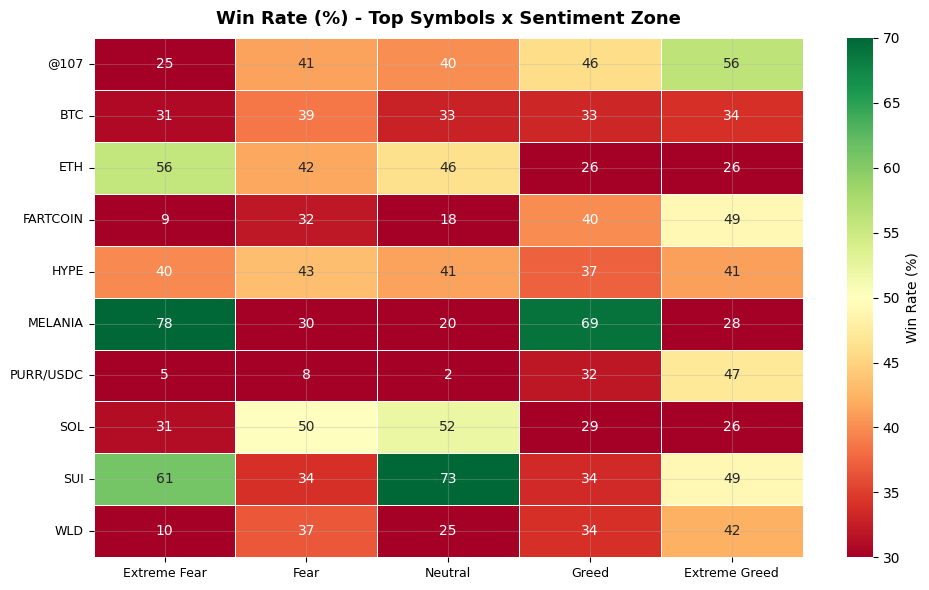

In [7]:
if "symbol" in analysis.columns and "closedPnL" in analysis.columns:
    top_symbols = analysis["symbol"].value_counts().head(10).index
    heat_data = (
        analysis[
            analysis["symbol"].isin(top_symbols)
        ]
        .groupby(["symbol", "classification"], observed=False)["closedPnL"]
        .apply(lambda x: round((x > 0).mean() * 100, 1))
        .unstack()
        .reindex(columns=[z for z in ZONE_ORDER if z in analysis["classification"].unique()])
    )

    if not heat_data.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.heatmap(
            heat_data,
            annot=True,
            fmt=".0f",
            cmap="RdYlGn",
            vmin=30,
            vmax=70,
            linewidths=0.5,
            ax=ax,
            cbar_kws={"label": "Win Rate (%)"},
        )
        style_axes(ax, "Win Rate (%) - Top Symbols x Sentiment Zone", "", "")
        plt.tight_layout()
        save_fig("09_symbol_zone_heatmap")
        plt.show()


In [8]:
trade_start = tr["date"].min()
trade_end = tr["date"].max()
trade_dates = pd.Index(tr["date"].dropna().unique())

ef_in_range = fg[
    (fg["classification"] == "Extreme Fear")
    & (fg["date"] >= trade_start)
    & (fg["date"] <= trade_end)
].copy()
ef_in_range["had_trade_activity"] = ef_in_range["date"].isin(trade_dates)

print("Trade date range:")
print(f"{trade_start} -> {trade_end}")
print()
print(f"Extreme Fear days in trade period : {len(ef_in_range)}")
print(f"Extreme Fear days with trades     : {int(ef_in_range['had_trade_activity'].sum())}")
print(f"Extreme Fear days without trades  : {int((~ef_in_range['had_trade_activity']).sum())}")


Trade date range:
2023-05-01 00:00:00 -> 2025-05-01 00:00:00

Extreme Fear days in trade period : 15
Extreme Fear days with trades     : 14
Extreme Fear days without trades  : 1


      date  value classification  had_trade_activity
2024-08-06     17   Extreme Fear                True
2024-08-08     20   Extreme Fear                True
2024-09-06     22   Extreme Fear                True
2024-09-07     23   Extreme Fear               False
2025-02-26     21   Extreme Fear                True
2025-02-27     10   Extreme Fear                True
2025-02-28     16   Extreme Fear                True
2025-03-01     20   Extreme Fear                True
2025-03-04     15   Extreme Fear                True
2025-03-05     20   Extreme Fear                True
2025-03-10     20   Extreme Fear                True
2025-03-11     24   Extreme Fear                True
2025-04-07     23   Extreme Fear                True
2025-04-08     24   Extreme Fear                True
2025-04-09     18   Extreme Fear                True

--- KEY INSIGHT ---
Trade activity occurred on some Extreme Fear days, but not on all of them.
Saved -> C:\project\trading_sentiment_project\outputs\ch

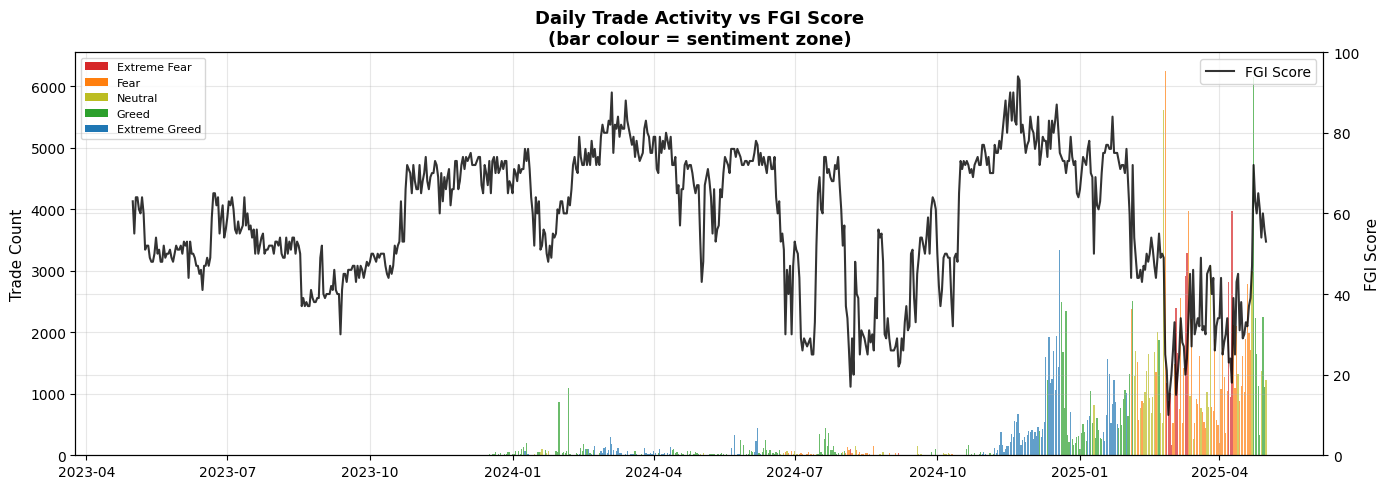

In [9]:
print(ef_in_range[["date", "value", "classification", "had_trade_activity"]].to_string(index=False))
print("\n--- KEY INSIGHT ---")
if ef_in_range["had_trade_activity"].all():
    print("Every Extreme Fear day in the trade window had at least some trade activity.")
elif (~ef_in_range["had_trade_activity"]).all():
    print("No Extreme Fear day in the trade window had any trade activity.")
else:
    print("Trade activity occurred on some Extreme Fear days, but not on all of them.")

daily_count = tr.groupby("date").size().reset_index(name="trade_count")
daily_activity = fg[
    (fg["date"] >= trade_start) & (fg["date"] <= trade_end)
][["date", "value", "classification"]].copy()
daily_activity = daily_activity.merge(daily_count, on="date", how="left")
daily_activity["trade_count"] = daily_activity["trade_count"].fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(14, 5))
ax2 = ax.twinx()

zone_color_map = {
    "Extreme Fear": "#d62728",
    "Fear": "#ff7f0e",
    "Neutral": "#bcbd22",
    "Greed": "#2ca02c",
    "Extreme Greed": "#1f77b4",
}
bar_colors = daily_activity["classification"].map(zone_color_map).fillna("#cccccc")

ax.bar(
    daily_activity["date"],
    daily_activity["trade_count"],
    color=bar_colors,
    alpha=0.7,
    label="Daily Trade Count",
)
ax2.plot(
    daily_activity["date"],
    daily_activity["value"],
    color="black",
    lw=1.5,
    alpha=0.8,
    label="FGI Score",
)

ax.set_ylabel("Trade Count", fontsize=11)
ax2.set_ylabel("FGI Score", fontsize=11)
ax2.set_ylim(0, 100)
ax.set_title(
    "Daily Trade Activity vs FGI Score\n(bar colour = sentiment zone)",
    fontsize=13,
    fontweight="bold",
)

from matplotlib.patches import Patch

legend_elements = [Patch(facecolor=c, label=z) for z, c in zone_color_map.items()]
ax.legend(handles=legend_elements, loc="upper left", fontsize=8)

lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines2, labels2, loc="upper right")

plt.tight_layout()
save_fig("extreme_fear_activity")
plt.show()


In [10]:
print(f"Total rows in trades_clean : {len(tr):,}")
print(f"Unique trade dates         : {tr['date'].nunique()}")
print("\nTrades per date:")
print(tr.groupby("date").size().sort_values(ascending=False).to_string())


Total rows in trades_clean : 211,224
Unique trade dates         : 480

Trades per date:
date
2025-02-25    6246
2025-04-23    6159
2025-02-24    5616
2025-03-12    3968
2025-04-09    3967
2024-12-19    3339
2025-03-11    3286
2025-03-26    3102
2025-04-22    2998
2025-03-10    2911
2025-04-07    2814
2025-04-19    2786
2025-03-07    2552
2025-02-04    2512
2024-12-20    2488
2025-03-04    2402
2025-02-03    2380
2024-12-23    2347
2025-04-29    2243
2025-04-24    2232
2025-03-14    2210
2025-04-10    2127
2025-04-12    2109
2025-02-20    2012
2025-04-20    1982
2024-12-17    1941
2024-12-12    1932
2025-04-18    1894
2025-03-29    1894
2025-02-21    1873
2025-04-03    1748
2025-04-21    1718
2025-02-06    1703
2024-12-15    1697
2024-12-21    1681
2025-02-18    1676
2025-03-05    1660
2025-02-14    1655
2025-04-25    1653
2025-03-19    1612
2025-04-16    1608
2024-12-10    1596
2025-01-19    1567
2025-02-07    1524
2025-03-03    1482
2024-12-18    1429
2025-03-09    1422
2025-04-28    